Filtering

In [1]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import signal


# Local MIT-BIH folder path (already downloaded)
mit_bih_path = r"C:\datasets\mit-bih-arrhythmia-database-1.0.0"

# Output root for annotations + manifest
annotations_path = r"C:\repos\ecg-dataset-single-lead\mit-bih"

# Target sampling rate
target_fs = 125

In [2]:
def init_stateful_bandpass_filter(fs=125, lowcut=0.5, highcut=40.0, order=2):
    """
    Initialize a low-compute causal bandpass filter state (SOS IIR).

    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    if not (0 < low < high < 1):
        raise ValueError("Invalid cutoff frequencies. Need 0 < lowcut < highcut < fs/2")

    sos = signal.butter(order, [low, high], btype="bandpass", output="sos")

    return {
        "fs": int(fs),
        "sos": sos,
        "zi": None,
        "next_sample": None,
        "lowcut": float(lowcut),
        "highcut": float(highcut),
        "order": int(order),
    }


def filter_window_stateful(window_samples, filter_state, window_start_sample=None):
    """
    Causal low-compute filtering for repeated 2-second windows.

    Important:
    - In overlapping mode, this function filters ONLY the new tail (unseen samples)
      to keep filter state correct without caching old outputs.
    - Returned signal is therefore the new filtered segment, not the full window.

    Parameters
    ----------
    window_samples : array-like
        Current window (typically 2 seconds).
    filter_state : dict
        State from init_stateful_bandpass_filter(...), updated in-place.
    window_start_sample : int or None
        Absolute sample index for first sample in this window.

    Returns
    -------
    filtered_new_only : np.ndarray
        Filtered samples that are new in time.
    meta : dict
        overlap/new sample counts and index info.
    """
    x = np.asarray(window_samples, dtype=np.float64)
    if x.ndim != 1:
        x = x.reshape(-1)

    if len(x) == 0:
        return np.array([], dtype=np.float64), {"overlap_samples": 0, "new_samples": 0}

    sos = filter_state["sos"]

    # Initialize filter memory using the first observed sample.
    if filter_state["zi"] is None:
        filter_state["zi"] = signal.sosfilt_zi(sos) * x[0]

    # If no index is provided, assume strictly contiguous chunks (no overlap handling).
    if window_start_sample is None:
        y_new, filter_state["zi"] = signal.sosfilt(sos, x, zi=filter_state["zi"])

        if filter_state["next_sample"] is None:
            start = 0
            filter_state["next_sample"] = len(x)
        else:
            start = filter_state["next_sample"]
            filter_state["next_sample"] += len(x)

        meta = {
            "overlap_samples": 0,
            "new_samples": int(len(y_new)),
            "window_start_sample": int(start),
            "window_end_sample": int(start + len(x) - 1),
        }
        return y_new, meta

    # Indexed mode: support overlap by skipping already-processed prefix.
    window_start_sample = int(window_start_sample)

    if filter_state["next_sample"] is None:
        overlap_len = 0
    else:
        overlap_len = max(0, filter_state["next_sample"] - window_start_sample)
    overlap_len = min(overlap_len, len(x))

    x_new = x[overlap_len:]

    if len(x_new) > 0:
        y_new, filter_state["zi"] = signal.sosfilt(sos, x_new, zi=filter_state["zi"])
    else:
        y_new = np.array([], dtype=np.float64)

    new_start = window_start_sample + overlap_len
    if filter_state["next_sample"] is None:
        filter_state["next_sample"] = new_start + len(y_new)
    else:
        filter_state["next_sample"] = max(filter_state["next_sample"], new_start + len(y_new))

    meta = {
        "overlap_samples": int(overlap_len),
        "new_samples": int(len(y_new)),
        "window_start_sample": int(window_start_sample),
        "window_end_sample": int(window_start_sample + len(x) - 1),
        "new_start_sample": int(new_start) if len(y_new) > 0 else None,
        "new_end_sample": int(new_start + len(y_new) - 1) if len(y_new) > 0 else None,
    }
    return y_new, meta

This cell is just for testing the filter logic with simulated streaming of 1 second overlap

In [3]:
# # Simulation loop: first local record, 2-second windows with 1-second overlap
# # This emulates repeated calls where each call receives a 2-second window.

# # 1) Pick first record from local MIT-BIH folder
# local_dataset_dir = mit_bih_path
# record_ids_local = sorted({os.path.splitext(f)[0] for f in os.listdir(local_dataset_dir) if f.lower().endswith('.dat')})
# if not record_ids_local:
#     raise FileNotFoundError(f"No .dat records found in: {local_dataset_dir}")

# sim_record_id = record_ids_local[0]
# record = wfdb.rdrecord(os.path.join(local_dataset_dir, sim_record_id))
# df = pd.DataFrame(record.p_signal, columns=record.sig_name)

# if "MLII" not in df.columns:
#     raise ValueError(f"MLII not found in first record {sim_record_id}. Available leads: {record.sig_name}")

# # 2) Resample to 125 Hz to match embedded target pipeline
# x = df["MLII"].to_numpy(dtype=np.float64)
# orig_fs = float(record.fs)
# target_fs = 125
# new_len = int(len(x) * target_fs / orig_fs)
# x_125 = signal.resample(x, new_len)

# # 3) Create stateful filter and stream overlapping windows
# fstate = init_stateful_bandpass_filter(fs=target_fs, lowcut=0.5, highcut=40.0, order=2)

# win_size = 2 * target_fs   # 2 seconds
# hop_size = 1 * target_fs   # 1-second overlap -> hop is 1 second

# filtered_stream_parts = []
# meta_rows = []

# for start_idx in range(0, len(x_125) - win_size + 1, hop_size):
#     window = x_125[start_idx:start_idx + win_size]
#     y_new, meta = filter_window_stateful(window, fstate, window_start_sample=start_idx)

#     filtered_stream_parts.append(y_new)
#     meta_rows.append({
#         "window_start": start_idx,
#         "window_end": start_idx + win_size - 1,
#         "overlap_samples": meta["overlap_samples"],
#         "new_samples": meta["new_samples"],
#     })

# # 4) Reconstruct filtered continuous stream from new-only outputs
# filtered_stream = np.concatenate(filtered_stream_parts) if filtered_stream_parts else np.array([])
# meta_df = pd.DataFrame(meta_rows)

# print(f"Simulation record: {sim_record_id}")
# print(f"Original fs: {orig_fs} Hz -> Target fs: {target_fs} Hz")
# print(f"Windows processed: {len(meta_df)}")
# print(f"Total input samples @125Hz: {len(x_125)}")
# print(f"Total filtered new samples: {len(filtered_stream)}")

# # 5) Quick visual check (first 12 seconds)
# plot_n = min(12 * target_fs, len(filtered_stream))
# plt.figure(figsize=(12, 4))
# plt.plot(filtered_stream[:plot_n], linewidth=1.0, color="tab:green")
# plt.title(f"Stateful causal filtered stream (first {plot_n} samples) - record {sim_record_id}")
# plt.xlabel("Sample @125Hz")
# plt.ylabel("Filtered amplitude")
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

# meta_df.head(10)

## Peak_detector is the function where we will evaluate the detector algorithm. By default it has a peak detector from neurokit. 
Cindy, you can add your function here with this name (comment the current one to keep it for comparison), the rest of the logic should work (the function receives a 2 second window and has to output the samples where it detected R-peaks.)

In [4]:

#BASELINE DETECTOR FUNCTIONS
import neurokit2 as nk
def peak_detector(window_2s, fs=125):
    """
    Library-based detector using NeuroKit2.
    Input: 1D array of length ~250 (2 seconds at 125 Hz)
    Output: list of detected peak indices relative to window start.
    """
    window_2s = np.asarray(window_2s, dtype=np.float64)
    if len(window_2s) == 0:
        return []

    # NeuroKit2 returns a dict with key 'ECG_R_Peaks' (indices in this local window)
    # Method 'neurokit' is a good general default for ECG.
    try:
        _, info = nk.ecg_peaks(window_2s, sampling_rate=fs, method="neurokit", correct_artifacts=False)
        peaks = info.get("ECG_R_Peaks", [])
    except Exception:
        peaks = []

    return [int(p) for p in peaks if 0 <= int(p) < len(window_2s)]


def pan_tompkins_peak_detector(window_2s, fs=125):
    """
    Canonical Pan-Tompkins-style R-peak detector (window-local indices).

    Steps:
      1) Bandpass filter (~5-15 Hz)
      2) Derivative
      3) Squaring
      4) Moving-window integration (~150 ms)
      5) Adaptive threshold peak candidates + refractory
      6) R-peak localization on bandpassed signal

    Returns
    -------
    list[int]
        Peak indices relative to window start.
    """
    x = np.asarray(window_2s, dtype=np.float64).reshape(-1)
    n = len(x)
    if n < max(5, int(0.3 * fs)):
        return []

    # 1) Bandpass filter (Pan-Tompkins-inspired passband).
    low_hz, high_hz = 5.0, 15.0
    nyq = 0.5 * float(fs)
    low = max(1e-4, low_hz / nyq)
    high = min(0.999, high_hz / nyq)
    if not (0 < low < high < 1):
        return []

    try:
        b, a = signal.butter(2, [low, high], btype="bandpass")
        x_bp = signal.lfilter(b, a, x)
    except Exception:
        return []

    # 2) Derivative filter (Pan-Tompkins finite difference approximation).
    d_kernel = np.array([1, 2, 0, -2, -1], dtype=np.float64) / 8.0
    x_d = np.convolve(x_bp, d_kernel, mode="same")

    # 3) Squaring.
    x_sq = x_d * x_d

    # 4) Moving-window integration (~150 ms).
    mwi_len = max(1, int(round(0.150 * fs)))
    mwi_kernel = np.ones(mwi_len, dtype=np.float64) / mwi_len
    x_mwi = np.convolve(x_sq, mwi_kernel, mode="same")

    # 5) Candidate peaks on integrated signal.
    refractory = max(1, int(round(0.200 * fs)))  # 200 ms
    thr = float(np.mean(x_mwi) + 0.5 * np.std(x_mwi))
    if not np.isfinite(thr):
        return []

    cand_peaks, _ = signal.find_peaks(x_mwi, height=thr, distance=refractory)
    if len(cand_peaks) == 0:
        return []

    # 6) Refine each candidate to true R on bandpassed signal.
    search_radius = max(1, int(round(0.120 * fs)))  # ±120 ms
    refined = []

    for p in cand_peaks:
        left = max(0, int(p) - search_radius)
        right = min(n, int(p) + search_radius + 1)
        if right <= left:
            continue

        local = x_bp[left:right]
        if local.size == 0:
            continue

        # R can be positive or negative depending on lead polarity.
        offset = int(np.argmax(np.abs(local)))
        r_idx = left + offset
        refined.append(r_idx)

    if len(refined) == 0:
        return []

    # De-duplicate with refractory constraint on refined peaks.
    refined = sorted(int(r) for r in refined if 0 <= int(r) < n)
    dedup = [refined[0]]
    for r in refined[1:]:
        if (r - dedup[-1]) >= refractory:
            dedup.append(r)
        elif np.abs(x_bp[r]) > np.abs(x_bp[dedup[-1]]):
            dedup[-1] = r

    return dedup


In [5]:
# R-peak detector evaluation framework (stream-style, 2-second windows)
def list_local_record_ids(local_dataset_dir):
    """Return sorted MIT-BIH record IDs from a local dataset directory."""
    record_ids = sorted({
        os.path.splitext(f)[0]
        for f in os.listdir(local_dataset_dir)
        if f.lower().endswith('.dat')
    })
    if not record_ids:
        raise FileNotFoundError(f"No .dat records found in: {local_dataset_dir}")
    return record_ids


def load_record_and_ground_truth(record_id, annotations_root, signal_mode="online_robust"):
    """
    Load one record by ID, then load:
      - precomputed 125 Hz signal from signals/<mode>/
      - GT R-peak samples from annotations CSV

    signal_mode options:
      - "online_robust"
      - "record_minmax"
    """
    # Resolve signal mode.
    mode_map = {
        "online_robust": "online_robust",
        "record_minmax": "record_minmax",
    }
    if signal_mode not in mode_map:
        raise ValueError("signal_mode must be 'online_robust' or 'record_minmax'")

    resolved_mode = mode_map[signal_mode]
    record_id = str(record_id)

    # Load precomputed 125 Hz signal from signals folder.
    signal_csv = os.path.join(
        annotations_root,
        "signals",
        resolved_mode,
        f"{record_id}_mlii_125hz_{'online' if resolved_mode == 'online_robust' else 'record'}.csv",
    )
    if not os.path.exists(signal_csv):
        raise FileNotFoundError(
            f"125 Hz signal CSV not found for record '{record_id}' mode '{resolved_mode}': {signal_csv}"
        )

    signal_df = pd.read_csv(signal_csv)
    if "MLII" not in signal_df.columns:
        raise ValueError(f"Signal CSV must contain 'MLII' column: {signal_csv}")

    x_125 = signal_df["MLII"].to_numpy(dtype=np.float64)

    # Load annotations (already aligned to 125 Hz)
    ann_csv = os.path.join(annotations_root, "annotations", f"{record_id}_annotations_125hz.csv")
    if not os.path.exists(ann_csv):
        raise FileNotFoundError(f"Annotation CSV not found: {ann_csv}")

    ann_df = pd.read_csv(ann_csv)

    # Keep beat-like annotations only (exclude rhythm marker '+').
    if "symbol" not in ann_df.columns or "sample_125" not in ann_df.columns:
        raise ValueError("Annotation CSV must contain 'symbol' and 'sample_125' columns")

    gt_samples = np.sort(ann_df.loc[ann_df["symbol"] != "+", "sample_125"].astype(int).to_numpy())

    return record_id, x_125, gt_samples, ann_df, signal_csv


def evaluate_rpeak_detector_stream(
    signal_1d,
    gt_samples,
    detector_fn,
    fs=125,
    window_sec=2,
    tolerance_ms=150,
    initial_prev_peak=None,
    apply_causal_filter=False,
    causal_filter_config=None,
    anchor_offset_samples=20,
):
    """
    Emulates embedded detector behavior:
      1) First window starts at sample 0 (length = window_sec * fs).
      2) After detecting an R-peak at sample r_k, next window starts at (r_k - anchor_offset_samples).
      3) For subsequent windows, ignore the first detected peak (expected carry-over near index ~anchor_offset_samples),
         and evaluate ONLY the second detected peak.
      4) Exception: for the very first beat, evaluate the first detected peak.

    detector_fn(window) or detector_fn(window, fs=...) returns relative peak positions.
    We translate the selected peak to absolute samples and match against GT within ±tolerance.

    Optional: apply a causal stateful bandpass filter before detector_fn.
    """
    signal_1d = np.asarray(signal_1d, dtype=np.float64)
    gt_samples = np.sort(np.asarray(gt_samples, dtype=int))

    window_size = int(window_sec * fs)
    tolerance = int(round((tolerance_ms / 1000.0) * fs))
    anchor_offset_samples = int(anchor_offset_samples)

    if window_size <= 0:
        raise ValueError("window_sec * fs must be > 0")
    if anchor_offset_samples < 0:
        raise ValueError("anchor_offset_samples must be >= 0")

    # If initial_prev_peak is provided, we already have a prior beat anchor;
    # then the next evaluated peak should be the second one in the window.
    if initial_prev_peak is None:
        prev_detected_peak = None
        first_beat_pending = True
    else:
        prev_detected_peak = int(initial_prev_peak)
        first_beat_pending = False

    # Optional causal filter setup.
    filter_state = None
    if apply_causal_filter:
        cfg = causal_filter_config or {}
        filter_state = init_stateful_bandpass_filter(
            fs=fs,
            lowcut=float(cfg.get("lowcut", 0.5)),
            highcut=float(cfg.get("highcut", 40.0)),
            order=int(cfg.get("order", 2)),
        )

    gt_matched = np.zeros(len(gt_samples), dtype=bool)
    events = []

    while True:
        # Embedded-style window placement.
        if prev_detected_peak is None:
            window_start = 0
        else:
            window_start = int(prev_detected_peak) - anchor_offset_samples

        if window_start < 0:
            window_start = 0
        window_end = window_start + window_size

        if window_end > len(signal_1d):
            break

        window_raw = signal_1d[window_start:window_end]

        # Optional causal filtering before detector call.
        if apply_causal_filter:
            detector_input, filter_meta = filter_window_stateful(
                window_raw,
                filter_state,
                window_start_sample=window_start,
            )
            detector_base_sample = (
                int(filter_meta["new_start_sample"])
                if filter_meta.get("new_start_sample") is not None
                else int(window_start)
)
        else:
            detector_input = window_raw
            detector_base_sample = int(window_start)

        # Support detectors with either signature: fn(window) or fn(window, fs=...).
        try:
            rel_peaks = detector_fn(detector_input, fs=fs)
        except TypeError:
            rel_peaks = detector_fn(detector_input)

        current_len = len(detector_input)
        rel_peaks = sorted([int(p) for p in rel_peaks if 0 <= int(p) < current_len])

        # Select evaluated peak according to embedded rule.
        evaluated_peak_rank = None
        selected_rel_peak = None

        if first_beat_pending:
            if len(rel_peaks) >= 1:
                selected_rel_peak = rel_peaks[0]
                evaluated_peak_rank = 1
        else:
            if len(rel_peaks) >= 2:
                selected_rel_peak = rel_peaks[1]
                evaluated_peak_rank = 2

        if selected_rel_peak is not None:
            detected_abs = detector_base_sample + selected_rel_peak

            # Match to nearest unmatched GT within tolerance.
            unmatched_idx = np.where(~gt_matched)[0]
            matched_gt = None
            error_samples = None
            is_correct = False

            if len(unmatched_idx) > 0:
                candidate_gt = gt_samples[unmatched_idx]
                diffs = np.abs(candidate_gt - detected_abs)
                within_tol = np.where(diffs <= tolerance)[0]

                if len(within_tol) > 0:
                    best_local = within_tol[np.argmin(diffs[within_tol])]
                    best_idx = unmatched_idx[best_local]
                    gt_matched[best_idx] = True
                    matched_gt = int(gt_samples[best_idx])
                    error_samples = int(detected_abs - matched_gt)
                    is_correct = True

            events.append({
                "window_start": int(window_start),
                "window_end": int(window_end - 1),
                "detected_abs": int(detected_abs),
                "matched_gt": matched_gt,
                "error_samples": error_samples,
                "is_correct": bool(is_correct),
                "n_detected_in_window": int(len(rel_peaks)),
                "evaluated_peak_rank": evaluated_peak_rank,
            })

            # This selected beat becomes anchor for next window.
            prev_detected_peak = int(detected_abs)
            first_beat_pending = False

        else:
            # No evaluable peak in this window (e.g., no peaks, or only 1 peak in non-first window).
            events.append({
                "window_start": int(window_start),
                "window_end": int(window_end - 1),
                "detected_abs": None,
                "matched_gt": None,
                "error_samples": None,
                "is_correct": False,
                "n_detected_in_window": int(len(rel_peaks)),
                "evaluated_peak_rank": None,
            })

            # Advance safely in time to avoid stalling.
            prev_detected_peak = int(window_start + window_size)

    events_df = pd.DataFrame(events)

    tp = int(events_df["is_correct"].sum())
    fp = int(events_df["detected_abs"].notna().sum() - tp)
    fn = int((~gt_matched).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    detection_error_rate = (fp + fn) / (tp + fn) if (tp + fn) > 0 else 0.0

    summary = {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision / ppv": precision,
        "recall / sensitivity": recall,
        "f1": f1,
        "detection_error_rate": detection_error_rate,
        "tolerance_samples": tolerance,
        "tolerance_ms": tolerance_ms,
        "windows_processed": int(len(events_df)),
        "apply_causal_filter": bool(apply_causal_filter),
        "anchor_offset_samples": int(anchor_offset_samples),
    }

    return events_df, summary

def plot_fp_fn_examples(events_df, signal_1d, gt_samples, fs=125, max_events=6, segment_sec=2.0):
    """
    Plot up to max_events examples of false positives and false negatives.

    Parameters
    ----------
    events_df : pd.DataFrame
        Output from evaluate_rpeak_detector_stream(...)
    signal_1d : array-like
        ECG signal used during evaluation (same indexing as gt_samples)
    gt_samples : array-like
        Ground-truth R-peak absolute sample indices
    fs : int
        Sampling rate in Hz
    max_events : int
        Maximum number of FP/FN examples to plot
    segment_sec : float
        Segment duration in seconds for each example (default 2 s)
    """
    signal_1d = np.asarray(signal_1d, dtype=np.float64)
    gt_samples = np.sort(np.asarray(gt_samples, dtype=int))

    if max_events <= 0:
        print("max_events <= 0, nothing to plot.")
        return

    segment_len = int(round(segment_sec * fs))
    segment_len = max(segment_len, 1)
    half_len = segment_len // 2

    # False positives: detected peak exists but event is not correct.
    fp_df = events_df[(events_df["detected_abs"].notna()) & (~events_df["is_correct"])].copy()
    fp_centers = fp_df["detected_abs"].astype(int).tolist()

    # False negatives: GT peaks that were never matched by any event.
    matched_gt = events_df["matched_gt"].dropna().astype(int).unique()
    matched_gt_set = set(matched_gt.tolist())
    fn_centers = [int(g) for g in gt_samples if int(g) not in matched_gt_set]

    # Select up to max_events total, roughly balanced FP/FN.
    n_fp = min(len(fp_centers), max_events // 2)
    n_fn = min(len(fn_centers), max_events - n_fp)

    # If one side has fewer examples, fill the remaining slots from the other side.
    remaining = max_events - (n_fp + n_fn)
    if remaining > 0:
        extra_fp = min(remaining, len(fp_centers) - n_fp)
        n_fp += extra_fp
        remaining -= extra_fp
    if remaining > 0:
        extra_fn = min(remaining, len(fn_centers) - n_fn)
        n_fn += extra_fn

    selected = ([('FP', c) for c in fp_centers[:n_fp]] + [('FN', c) for c in fn_centers[:n_fn]])

    if len(selected) == 0:
        print("No false positives or false negatives found for plotting.")
        return

    # All detected peaks (for overlay within each displayed segment)
    all_detected = events_df["detected_abs"].dropna().astype(int).to_numpy()

    fig, axes = plt.subplots(len(selected), 1, figsize=(14, 3 * len(selected)), squeeze=False)

    for i, (etype, center) in enumerate(selected):
        ax = axes[i, 0]

        start = max(0, center - half_len)
        end = min(len(signal_1d), start + segment_len)
        if end - start < segment_len:
            start = max(0, end - segment_len)

        seg = signal_1d[start:end]
        x = np.arange(start, end)

        ax.plot(x, seg, color="tab:blue", linewidth=1.0)

        # Overlay GT peaks in this segment
        gt_in_seg = gt_samples[(gt_samples >= start) & (gt_samples < end)]
        if len(gt_in_seg) > 0:
            ax.scatter(
                gt_in_seg,
                signal_1d[gt_in_seg],
                color="limegreen",
                s=28,
                zorder=3,
                label="GT R-peaks"
            )

        # Overlay detected peaks in this segment
        det_in_seg = all_detected[(all_detected >= start) & (all_detected < end)]
        if len(det_in_seg) > 0:
            ax.scatter(
                det_in_seg,
                signal_1d[det_in_seg],
                color="crimson",
                s=28,
                zorder=3,
                label="Detected R-peaks"
            )

        # Highlight the event center with a vertical dashed line
        ax.axvline(center, color="black", linestyle="--", linewidth=1.0, alpha=0.8)

        ax.set_title(f"{etype} example {i+1}: center sample {center} | segment [{start}, {end})")
        ax.set_xlabel("Absolute sample")
        ax.set_ylabel("Amplitude")
        ax.grid(True, linestyle="--", alpha=0.4)

        # Prevent duplicate legend entries.
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            ax.legend(unique.values(), unique.keys(), loc="upper right")

    plt.tight_layout()
    plt.show()



In [6]:
#Evaluate and plot one record at a time
RECORD_INDEX_TO_EVALUATE = 0  # Cindy, we can change this to evaluate and plot different patients 

# Choose which precomputed 125 Hz signal set to evaluate:
#   - "online_robust"  #Uses a causal normalization (appropriate for online use)
#   - "record_minmax"  #It uses a per-record normalization (peeks into the future)
signal_mode_eval = "record_minmax"

# Choose detector function to evaluate:
#   - peak_detector (NeuroKit2)
#   - pan_tompkins_peak_detector (canonical Pan-Tompkins-style)
# Cindy you can plot here your functions evaluating on the chosen record
detector_fn_eval = pan_tompkins_peak_detector

# Toggle causal pre-filter before peak detector.
apply_causal_filter_eval = False
causal_filter_config_eval = {
    "lowcut": 0.5,
    "highcut": 40.0,
    "order": 2,
}

# Example behavior: retrieve and evaluate the first available record ID.
record_ids_local = list_local_record_ids(mit_bih_path)
record_id_eval_target = record_ids_local[RECORD_INDEX_TO_EVALUATE]

record_id_eval, x_eval, gt_eval, ann_eval, signal_csv_used = load_record_and_ground_truth(
    record_id=record_id_eval_target,
    annotations_root=annotations_path,
    signal_mode=signal_mode_eval,
)

events_df, summary = evaluate_rpeak_detector_stream(
    signal_1d=x_eval,
    gt_samples=gt_eval,
    detector_fn=detector_fn_eval,
    fs=target_fs,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=apply_causal_filter_eval,
    causal_filter_config=causal_filter_config_eval,
    anchor_offset_samples=20,
)

print(f"Record evaluated: {record_id_eval}")
print(f"Signal source:   {signal_csv_used}")
print(f"Detector:        {detector_fn_eval.__name__}")
print(f"Causal filter:   {apply_causal_filter_eval} | config={causal_filter_config_eval}")
print(pd.Series(summary))

events_df.head(15)


Record evaluated: 100
Signal source:   C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\100_mlii_125hz_record.csv
Detector:        pan_tompkins_peak_detector
Causal filter:   False | config={'lowcut': 0.5, 'highcut': 40.0, 'order': 2}
tp                           2269
fp                              0
fn                              4
precision / ppv               1.0
recall / sensitivity      0.99824
f1                       0.999119
detection_error_rate      0.00176
tolerance_samples              19
tolerance_ms                  150
windows_processed            2269
apply_causal_filter         False
anchor_offset_samples          20
dtype: object


,window_start,window_end,detected_abs,matched_gt,error_samples,is_correct,n_detected_in_window,evaluated_peak_rank
0,0,249,33,27,6,True,3,1
1,13,262,135,128,7,True,3,2
2,115,364,236,230,6,True,3,2
3,216,465,335,328,7,True,3,2
4,315,564,434,427,7,True,3,2
5,414,663,532,526,6,True,3,2
6,512,761,634,628,6,True,3,2
7,614,863,716,710,6,True,3,2
8,696,945,840,834,6,True,3,2
9,820,1069,946,940,6,True,3,2


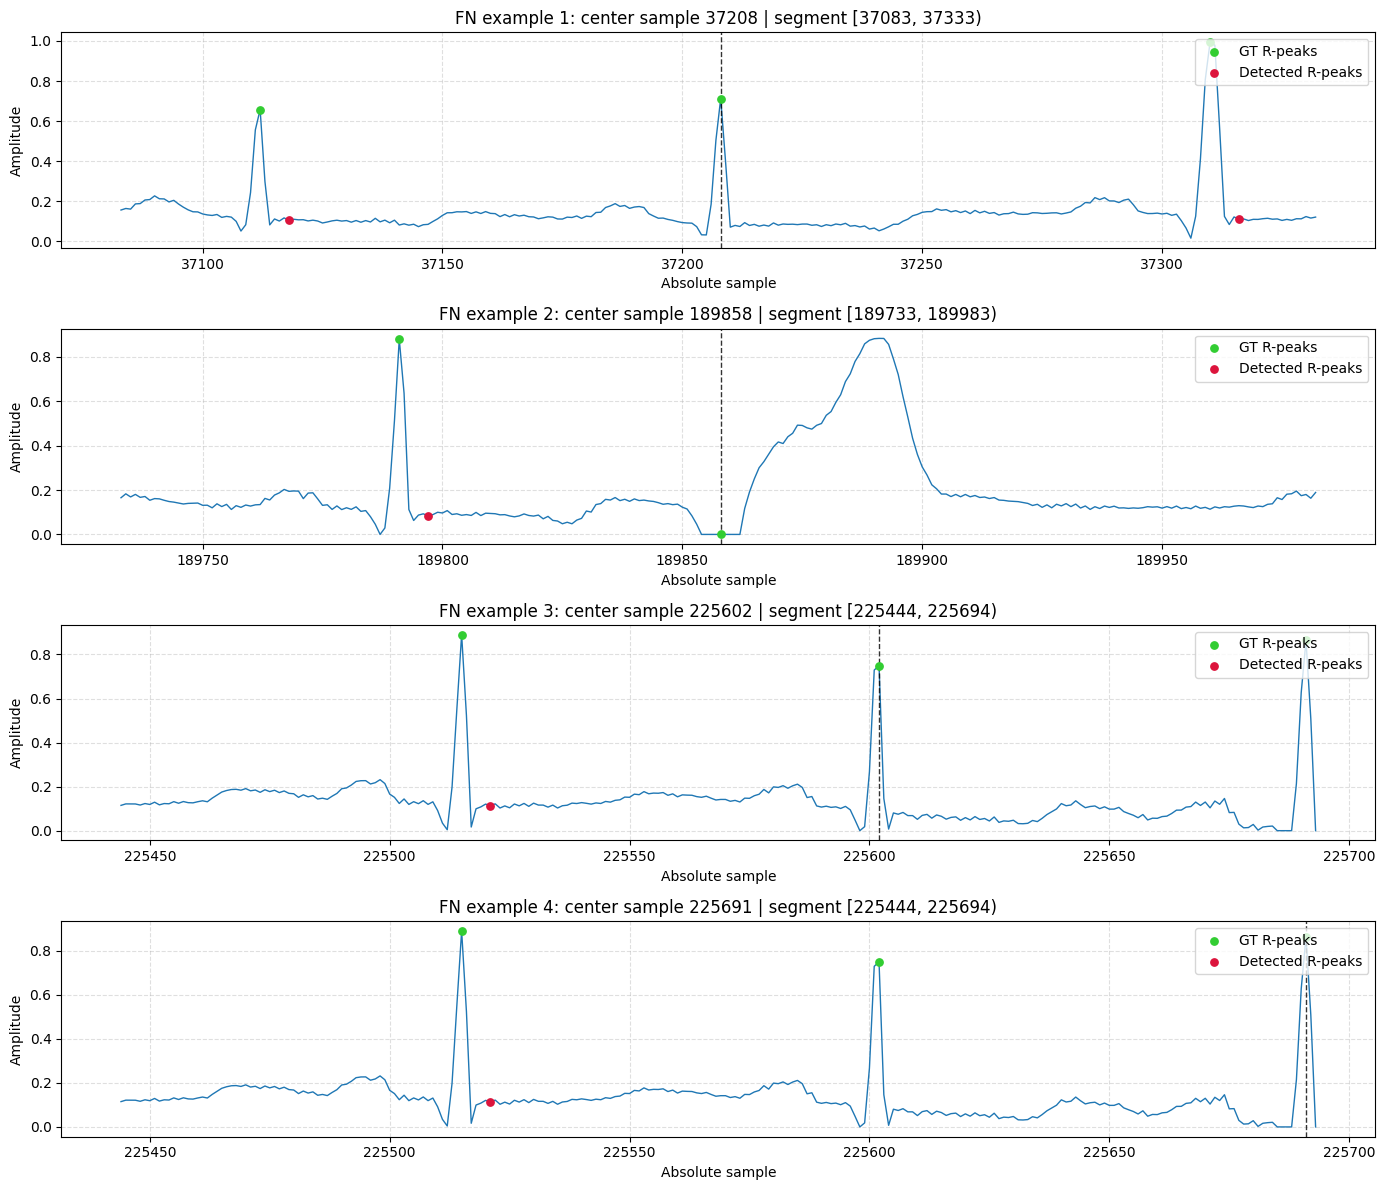

In [7]:


# Example usage (after events_df, x_eval, gt_eval exist):
plot_fp_fn_examples(
    events_df=events_df,
    signal_1d=x_eval,
    gt_samples=gt_eval,
    fs=target_fs,
    max_events=8,
    segment_sec=2.0,
)

## After the example that analyzed the first record, we want to evaluate all records

In [8]:
def plot_detection_confusion_matrix(tp, fp, fn, title="Beat Detection Confusion Matrix (All Records)"):
    """
    Plot an aggregate beat-detection confusion matrix.

    Matrix layout:
        rows   = actual    [Beat, No-Beat]
        cols   = predicted [Beat, No-Beat]

    Note: For event-level ECG beat detection, TN is typically not meaningful in this setup,
    so TN is set to 0 for a beat-centric summary view.
    """
    cm = np.array([[int(tp), int(fn)], [int(fp), 0]], dtype=np.int64)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Beat", "Pred: No-Beat"])
    ax.set_yticklabels(["Actual: Beat", "Actual: No-Beat"])
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            ax.text(
                j,
                i,
                f"{value}",
                ha="center",
                va="center",
                color="white" if value > cm.max() * 0.5 else "black",
                fontsize=11,
                fontweight="bold",
            )

    plt.tight_layout()
    plt.show()


def evaluate_all_records(
    local_dataset_dir,
    annotations_root,
    detector_fn,
    fs=125,
    signal_mode="record_minmax",
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=False,
    causal_filter_config=None,
    output_csv_filename=None,
    plot_confusion=True,
    verbose=True,
    plot_title = "Beat Detection Confusion Matrix (All Records)",
):
    """
    Evaluate the detector across all local records and save per-record results.

    Returns
    -------
    results_df : pd.DataFrame
        Per-record metrics and metadata.
    overall_summary : dict
        Aggregated metrics across all successfully evaluated records.
    output_csv_path : str
        File path where results_df was saved.
    """
    record_ids = list_local_record_ids(local_dataset_dir)

    rows = []
    agg_tp, agg_fp, agg_fn = 0, 0, 0
    success_count, fail_count = 0, 0

    for rid in record_ids:
        try:
            record_id, x_125, gt_samples, ann_df, signal_csv_used = load_record_and_ground_truth(
                record_id=rid,
                annotations_root=annotations_root,
                signal_mode=signal_mode,
            )

            events_df_rec, summary_rec = evaluate_rpeak_detector_stream(
                signal_1d=x_125,
                gt_samples=gt_samples,
                detector_fn=detector_fn,
                fs=fs,
                window_sec=window_sec,
                tolerance_ms=tolerance_ms,
                apply_causal_filter=apply_causal_filter,
                causal_filter_config=causal_filter_config,
            )

            tp = int(summary_rec["tp"])
            fp = int(summary_rec["fp"])
            fn = int(summary_rec["fn"])

            agg_tp += tp
            agg_fp += fp
            agg_fn += fn
            success_count += 1

            rows.append({
                "record_id": record_id,
                "status": "ok",
                "signal_csv": signal_csv_used,
                "n_samples": int(len(x_125)),
                "n_gt_beats": int(len(gt_samples)),
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "precision_ppv": float(summary_rec["precision / ppv"]),
                "recall_sensitivity": float(summary_rec["recall / sensitivity"]),
                "f1": float(summary_rec["f1"]),
                "detection_error_rate": float(summary_rec["detection_error_rate"]),
                "windows_processed": int(summary_rec["windows_processed"]),
                "apply_causal_filter": bool(summary_rec["apply_causal_filter"]),
                "error_message": "",
            })

            if verbose:
                print(f"[OK] {record_id}: TP={tp}, FP={fp}, FN={fn}")

        except Exception as exc:
            fail_count += 1
            rows.append({
                "record_id": str(rid),
                "status": "failed",
                "signal_csv": "",
                "n_samples": np.nan,
                "n_gt_beats": np.nan,
                "tp": np.nan,
                "fp": np.nan,
                "fn": np.nan,
                "precision_ppv": np.nan,
                "recall_sensitivity": np.nan,
                "f1": np.nan,
                "detection_error_rate": np.nan,
                "windows_processed": np.nan,
                "apply_causal_filter": bool(apply_causal_filter),
                "error_message": str(exc),
            })

            if verbose:
                print(f"[FAILED] {rid}: {exc}")

    results_df = pd.DataFrame(rows)

    if output_csv_filename is None:
        output_csv_path = os.path.join(annotations_root, "evaluation", "all_records_results.csv")
    else:
        output_csv_path = os.path.join(annotations_root, "evaluation", output_csv_filename)
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
    results_df.to_csv(output_csv_path, index=False)

    micro_precision = agg_tp / (agg_tp + agg_fp) if (agg_tp + agg_fp) > 0 else 0.0
    micro_recall = agg_tp / (agg_tp + agg_fn) if (agg_tp + agg_fn) > 0 else 0.0
    micro_f1 = (2 * micro_precision * micro_recall / (micro_precision + micro_recall)) if (micro_precision + micro_recall) > 0 else 0.0
    micro_der = (agg_fp + agg_fn) / (agg_tp + agg_fn) if (agg_tp + agg_fn) > 0 else 0.0

    overall_summary = {
        "records_total": int(len(record_ids)),
        "records_success": int(success_count),
        "records_failed": int(fail_count),
        "tp_total": int(agg_tp),
        "fp_total": int(agg_fp),
        "fn_total": int(agg_fn),
        "micro_precision_ppv": float(micro_precision),
        "micro_recall_sensitivity": float(micro_recall),
        "micro_f1": float(micro_f1),
        "micro_detection_error_rate": float(micro_der),
        "tolerance_ms": int(tolerance_ms),
        "signal_mode": str(signal_mode),
        "apply_causal_filter": bool(apply_causal_filter),
        "output_csv": output_csv_path,
    }

    if plot_confusion and (agg_tp + agg_fp + agg_fn) > 0:
        plot_detection_confusion_matrix(
            tp=agg_tp,
            fp=agg_fp,
            fn=agg_fn,
            title=plot_title,
        )

    if verbose:
        print("\nAll-record evaluation summary:")
        print(pd.Series(overall_summary))
        print(f"\nSaved per-record results to: {output_csv_path}")

    return results_df, overall_summary, output_csv_path

## Baseline Neurokit

[OK] 100: TP=1128, FP=0, FN=1145
[OK] 101: TP=544, FP=43, FN=1329
[FAILED] 102: 125 Hz signal CSV not found for record '102' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\102_mlii_125hz_record.csv
[OK] 103: TP=809, FP=7, FN=1281
[FAILED] 104: 125 Hz signal CSV not found for record '104' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\104_mlii_125hz_record.csv
[OK] 105: TP=1275, FP=8, FN=1415
[OK] 106: TP=698, FP=8, FN=1359
[OK] 107: TP=900, FP=0, FN=1239
[OK] 108: TP=493, FP=168, FN=1330
[OK] 109: TP=1265, FP=0, FN=1269
[OK] 111: TP=982, FP=0, FN=1150
[OK] 112: TP=1269, FP=0, FN=1280
[OK] 113: TP=533, FP=26, FN=1262
[OK] 114: TP=574, FP=22, FN=1313
[OK] 115: TP=588, FP=76, FN=1373
[OK] 116: TP=1183, FP=0, FN=1237
[OK] 117: TP=455, FP=9, FN=1083
[OK] 118: TP=1113, FP=7, FN=1187
[OK] 119: TP=570, FP=37, FN=1421
[OK] 121: TP=587, FP=10, FN=1288
[OK] 122: TP=1236, FP=0, FN=1242
[OK] 123: TP=358, FP=63, FN=1160
[OK]

c:\Users\Antonio\anaconda3\envs\pytorch\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Antonio\anaconda3\envs\pytorch\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[OK] 201: TP=767, FP=37, FN=1237
[OK] 202: TP=869, FP=8, FN=1269
[OK] 203: TP=1361, FP=6, FN=1702
[OK] 205: TP=1300, FP=3, FN=1359
[OK] 207: TP=282, FP=27, FN=2079
[OK] 208: TP=1473, FP=0, FN=1514
[OK] 209: TP=1503, FP=0, FN=1528
[OK] 210: TP=1256, FP=1, FN=1412
[OK] 212: TP=1374, FP=0, FN=1388
[OK] 213: TP=1620, FP=0, FN=1631
[OK] 214: TP=1022, FP=3, FN=1250
[OK] 215: TP=1676, FP=0, FN=1719
[OK] 217: TP=978, FP=1, FN=1235
[OK] 219: TP=902, FP=11, FN=1389
[OK] 220: TP=640, FP=0, FN=1412
[OK] 221: TP=1085, FP=8, FN=1354
[OK] 222: TP=1161, FP=4, FN=1337
[OK] 223: TP=1299, FP=0, FN=1316
[OK] 228: TP=720, FP=35, FN=1380
[OK] 230: TP=958, FP=15, FN=1301
[OK] 231: TP=640, FP=80, FN=1360


c:\Users\Antonio\anaconda3\envs\pytorch\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Antonio\anaconda3\envs\pytorch\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[OK] 232: TP=721, FP=32, FN=1094
[OK] 233: TP=1535, FP=0, FN=1546
[OK] 234: TP=1375, FP=0, FN=1386


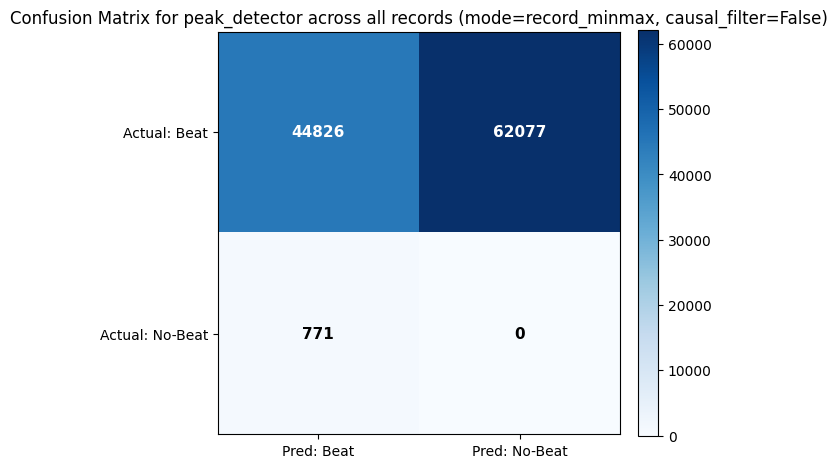


All-record evaluation summary:
records_total                                                                48
records_success                                                              46
records_failed                                                                2
tp_total                                                                  44826
fp_total                                                                    771
fn_total                                                                  62077
micro_precision_ppv                                                    0.983091
micro_recall_sensitivity                                               0.419315
micro_f1                                                               0.587882
micro_detection_error_rate                                             0.587897
tolerance_ms                                                                150
signal_mode                                                       record_minmax
apply_ca

,record_id,status,signal_csv,n_samples,n_gt_beats,tp,fp,fn,precision_ppv,recall_sensitivity,f1,detection_error_rate,windows_processed,apply_causal_filter,error_message
0,100,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2273.0,1128.0,0.0,1145.0,1.000000,0.496260,0.663334,0.503740,1136.0,False,
1,101,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1873.0,544.0,43.0,1329.0,0.926746,0.290443,0.442276,0.732515,1128.0,False,
2,102,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '102' m...
3,103,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2090.0,809.0,7.0,1281.0,0.991422,0.387081,0.556779,0.616268,1047.0,False,
4,104,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '104' m...
5,105,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2690.0,1275.0,8.0,1415.0,0.993765,0.473978,0.641832,0.528996,1292.0,False,
6,106,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2057.0,698.0,8.0,1359.0,0.988669,0.339329,0.505248,0.664560,1113.0,False,
7,107,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2139.0,900.0,0.0,1239.0,1.000000,0.420757,0.592300,0.579243,1068.0,False,
8,108,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1823.0,493.0,168.0,1330.0,0.745840,0.270433,0.396940,0.821722,1151.0,False,
9,109,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2534.0,1265.0,0.0,1269.0,1.000000,0.499211,0.665965,0.500789,1265.0,False,


In [9]:
## USE THE SAME CONFIG FOR ALL EVAL RUNS ##

APPLY_CAUSAL_FILTER = False  #We will use this kind of filter that doesnt look into the future in the Silicon Labs
CAUSAL_FILTER_CONFIG = {
    "lowcut": 0.5,
    "highcut": 40.0,
    "order": 2,
}
SIGNAL_MODE = "record_minmax"  # or "online_robust"    #Record minmax peeks into the future (we will implement online_robust in the Silicon Labs)

FUNCTION_TO_EVALUATE = peak_detector  
OUTPUT_CSV_FILENAME =  FUNCTION_TO_EVALUATE.__name__ + "_all_records_results.csv"   
## -------- Example run: evaluate ALL records --------
all_results_df, all_summary, all_results_csv = evaluate_all_records(
    local_dataset_dir=mit_bih_path,
    annotations_root=annotations_path,
    detector_fn=FUNCTION_TO_EVALUATE,
    fs=target_fs,
    signal_mode=SIGNAL_MODE,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=APPLY_CAUSAL_FILTER,
    causal_filter_config=CAUSAL_FILTER_CONFIG,
    output_csv_filename=OUTPUT_CSV_FILENAME,
    plot_confusion=True,
    verbose=True,
    plot_title = f"Confusion Matrix for {FUNCTION_TO_EVALUATE.__name__} across all records (mode={SIGNAL_MODE}, causal_filter={APPLY_CAUSAL_FILTER})"
)

all_results_df.head(10)

## Baseline Pan Tompkins

[OK] 100: TP=2269, FP=0, FN=4
[OK] 101: TP=1857, FP=1, FN=16
[FAILED] 102: 125 Hz signal CSV not found for record '102' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\102_mlii_125hz_record.csv
[OK] 103: TP=2078, FP=0, FN=12
[FAILED] 104: 125 Hz signal CSV not found for record '104' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\104_mlii_125hz_record.csv
[OK] 105: TP=2526, FP=22, FN=164
[OK] 106: TP=2003, FP=0, FN=54
[OK] 107: TP=2022, FP=22, FN=117
[OK] 108: TP=1652, FP=10, FN=171
[OK] 109: TP=2518, FP=1, FN=16
[OK] 111: TP=2071, FP=1, FN=61
[OK] 112: TP=2531, FP=0, FN=18
[OK] 113: TP=1793, FP=0, FN=2
[OK] 114: TP=1858, FP=0, FN=29
[OK] 115: TP=1951, FP=0, FN=10
[OK] 116: TP=2385, FP=2, FN=35
[OK] 117: TP=1529, FP=0, FN=9
[OK] 118: TP=2276, FP=0, FN=24
[OK] 119: TP=1986, FP=0, FN=5
[OK] 121: TP=1838, FP=1, FN=37
[OK] 122: TP=2474, FP=0, FN=4
[OK] 123: TP=1514, FP=0, FN=4
[OK] 124: TP=1575, FP=8, FN=46
[OK] 200:

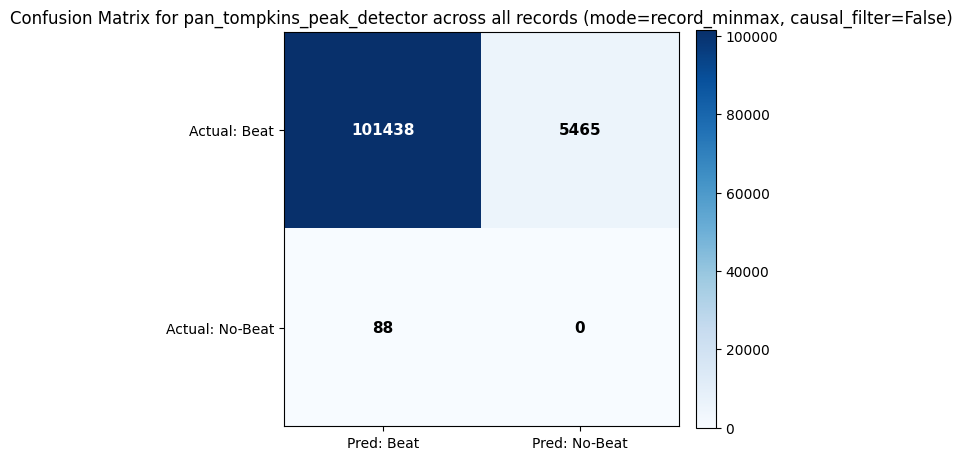


All-record evaluation summary:
records_total                                                                48
records_success                                                              46
records_failed                                                                2
tp_total                                                                 101438
fp_total                                                                     88
fn_total                                                                   5465
micro_precision_ppv                                                    0.999133
micro_recall_sensitivity                                               0.948879
micro_f1                                                               0.973358
micro_detection_error_rate                                             0.051944
tolerance_ms                                                                150
signal_mode                                                       record_minmax
apply_ca

,record_id,status,signal_csv,n_samples,n_gt_beats,tp,fp,fn,precision_ppv,recall_sensitivity,f1,detection_error_rate,windows_processed,apply_causal_filter,error_message
0,100,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2273.0,2269.0,0.0,4.0,1.000000,0.998240,0.999119,0.001760,2269.0,False,
1,101,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1873.0,1857.0,1.0,16.0,0.999462,0.991458,0.995444,0.009076,1861.0,False,
2,102,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '102' m...
3,103,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2090.0,2078.0,0.0,12.0,1.000000,0.994258,0.997121,0.005742,2079.0,False,
4,104,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '104' m...
5,105,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2690.0,2526.0,22.0,164.0,0.991366,0.939033,0.964490,0.069145,2552.0,False,
6,106,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2057.0,2003.0,0.0,54.0,1.000000,0.973748,0.986700,0.026252,2003.0,False,
7,107,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2139.0,2022.0,22.0,117.0,0.989237,0.945302,0.966770,0.064984,2049.0,False,
8,108,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1823.0,1652.0,10.0,171.0,0.993983,0.906199,0.948063,0.099287,1716.0,False,
9,109,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2534.0,2518.0,1.0,16.0,0.999603,0.993686,0.996636,0.006709,2519.0,False,


In [16]:
FUNCTION_TO_EVALUATE = pan_tompkins_peak_detector  

OUTPUT_CSV_FILENAME =  FUNCTION_TO_EVALUATE.__name__ + "_all_records_results.csv"   
## -------- Example run: evaluate ALL records --------
all_results_df, all_summary, all_results_csv = evaluate_all_records(
    local_dataset_dir=mit_bih_path,
    annotations_root=annotations_path,
    detector_fn=FUNCTION_TO_EVALUATE,
    fs=target_fs,
    signal_mode=SIGNAL_MODE,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=APPLY_CAUSAL_FILTER,
    causal_filter_config=CAUSAL_FILTER_CONFIG,
    output_csv_filename=OUTPUT_CSV_FILENAME,
    plot_confusion=True,
    verbose=True,
    plot_title = f"Confusion Matrix for {FUNCTION_TO_EVALUATE.__name__} across all records (mode={SIGNAL_MODE}, causal_filter={APPLY_CAUSAL_FILTER})"
)

all_results_df.head(10)

### Sanity check - Check if all r-peaks from GT are accounted for in the events_df and all_results_df, and check for duplicates. ###

In [11]:
# # Diagnostics: GT accounting and duplicate detection checks

# # 1) Single-record checks from current events_df / gt_eval
# detected_series = events_df["detected_abs"].dropna().astype(int)
# matched_series = events_df["matched_gt"].dropna().astype(int)

# single_record_diag = {
#     "record_id": record_id_eval,
#     "gt_count": int(len(gt_eval)),
#     "detected_count": int(len(detected_series)),
#     "detected_unique_count": int(detected_series.nunique()),
#     "detected_repeats": int(len(detected_series) - detected_series.nunique()),
#     "matched_gt_count": int(len(matched_series)),
#     "matched_gt_unique_count": int(matched_series.nunique()),
#     "matched_gt_repeats": int(len(matched_series) - matched_series.nunique()),
#     "tp_plus_fn_equals_gt": int(summary["tp"] + summary["fn"]) == int(len(gt_eval)),
# }

# print("Single-record diagnostic:")
# print(pd.Series(single_record_diag))

# # 2) All-record checks from all_results_df (successful rows only)
# ok_df = all_results_df[all_results_df["status"] == "ok"].copy()

# gt_total_ok = int(ok_df["n_gt_beats"].sum())
# tp_total_ok = int(ok_df["tp"].sum())
# fn_total_ok = int(ok_df["fn"].sum())

# all_records_diag = {
#     "records_ok": int(len(ok_df)),
#     "gt_total_ok": gt_total_ok,
#     "tp_total_ok": tp_total_ok,
#     "fn_total_ok": fn_total_ok,
#     "tp_plus_fn_equals_gt_total": (tp_total_ok + fn_total_ok) == gt_total_ok,
# }

# print("\nAll-record diagnostic:")
# print(pd.Series(all_records_diag))

# # Show any per-record accounting mismatches (should be none).
# mismatch_df = ok_df[(ok_df["tp"] + ok_df["fn"]) != ok_df["n_gt_beats"]]
# print("\nPer-record accounting mismatches (tp + fn != n_gt_beats):")
# print(mismatch_df[["record_id", "n_gt_beats", "tp", "fn"]].head(20))

## Evaluating other algorithms

In [12]:
from rpeak_algos import sma_detector, hc_detector

[OK] 100: TP=263, FP=4279, FN=2010
[OK] 101: TP=1496, FP=2628, FN=377
[FAILED] 102: 125 Hz signal CSV not found for record '102' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\102_mlii_125hz_record.csv
[OK] 103: TP=1610, FP=2802, FN=480
[FAILED] 104: 125 Hz signal CSV not found for record '104' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\104_mlii_125hz_record.csv
[OK] 105: TP=999, FP=3660, FN=1691
[OK] 106: TP=1274, FP=3048, FN=783
[OK] 107: TP=749, FP=3352, FN=1390
[OK] 108: TP=1677, FP=2043, FN=146
[OK] 109: TP=2394, FP=1140, FN=140
[OK] 111: TP=601, FP=3664, FN=1531
[OK] 112: TP=1919, FP=3127, FN=630
[OK] 113: TP=997, FP=2652, FN=798
[OK] 114: TP=861, FP=3613, FN=1026
[OK] 115: TP=1555, FP=2573, FN=406
[OK] 116: TP=1825, FP=2809, FN=595
[OK] 117: TP=1487, FP=1653, FN=51
[OK] 118: TP=2265, FP=2454, FN=35
[OK] 119: TP=1669, FP=2069, FN=322
[OK] 121: TP=963, FP=2717, FN=912
[OK] 122: TP=292, FP=4627, FN=2186

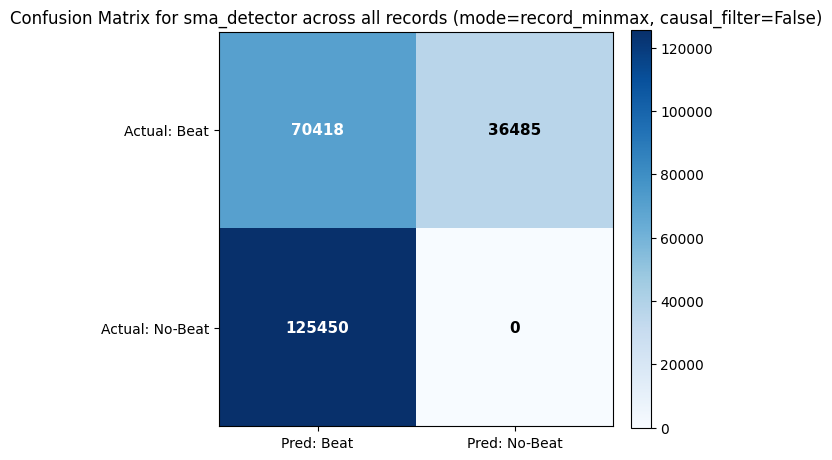


All-record evaluation summary:
records_total                                                                48
records_success                                                              46
records_failed                                                                2
tp_total                                                                  70418
fp_total                                                                 125450
fn_total                                                                  36485
micro_precision_ppv                                                    0.359518
micro_recall_sensitivity                                               0.658709
micro_f1                                                               0.465157
micro_detection_error_rate                                             1.514784
tolerance_ms                                                                150
signal_mode                                                       record_minmax
apply_ca

,record_id,status,signal_csv,n_samples,n_gt_beats,tp,fp,fn,precision_ppv,recall_sensitivity,f1,detection_error_rate,windows_processed,apply_causal_filter,error_message
0,100,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2273.0,263.0,4279.0,2010.0,0.057904,0.115706,0.077183,2.766828,4542.0,False,
1,101,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1873.0,1496.0,2628.0,377.0,0.362755,0.798719,0.498916,1.604378,4124.0,False,
2,102,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '102' m...
3,103,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2090.0,1610.0,2802.0,480.0,0.364914,0.770335,0.495232,1.570335,4412.0,False,
4,104,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '104' m...
5,105,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2690.0,999.0,3660.0,1691.0,0.214424,0.371375,0.271874,1.989219,4659.0,False,
6,106,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2057.0,1274.0,3048.0,783.0,0.294771,0.619349,0.399436,1.862421,4322.0,False,
7,107,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2139.0,749.0,3352.0,1390.0,0.182638,0.350164,0.240064,2.216924,4101.0,False,
8,108,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1823.0,1677.0,2043.0,146.0,0.450806,0.919912,0.605087,1.200768,3723.0,False,
9,109,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2534.0,2394.0,1140.0,140.0,0.677419,0.944751,0.789057,0.505130,3534.0,False,


In [17]:
FUNCTION_TO_EVALUATE = sma_detector  

OUTPUT_CSV_FILENAME =  FUNCTION_TO_EVALUATE.__name__ + "_all_records_results.csv"   
## -------- Example run: evaluate ALL records --------
all_results_df, all_summary, all_results_csv = evaluate_all_records(
    local_dataset_dir=mit_bih_path,
    annotations_root=annotations_path,
    detector_fn=FUNCTION_TO_EVALUATE,
    fs=target_fs,
    signal_mode=SIGNAL_MODE,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=APPLY_CAUSAL_FILTER,
    causal_filter_config=CAUSAL_FILTER_CONFIG,
    output_csv_filename=OUTPUT_CSV_FILENAME,
    plot_confusion=True,
    verbose=True,
    plot_title = f"Confusion Matrix for {FUNCTION_TO_EVALUATE.__name__} across all records (mode={SIGNAL_MODE}, causal_filter={APPLY_CAUSAL_FILTER})"
)

all_results_df.head(10)

[OK] 100: TP=2270, FP=7724, FN=3
[OK] 101: TP=1866, FP=9740, FN=7
[FAILED] 102: 125 Hz signal CSV not found for record '102' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\102_mlii_125hz_record.csv
[OK] 103: TP=2084, FP=5185, FN=6
[FAILED] 104: 125 Hz signal CSV not found for record '104' mode 'record_minmax': C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\104_mlii_125hz_record.csv
[OK] 105: TP=2643, FP=10471, FN=47
[OK] 106: TP=2034, FP=9271, FN=23
[OK] 107: TP=2133, FP=7129, FN=6
[OK] 108: TP=1785, FP=8184, FN=38
[OK] 109: TP=2525, FP=5515, FN=9
[OK] 111: TP=2118, FP=5255, FN=14
[OK] 112: TP=2543, FP=7854, FN=6
[OK] 113: TP=1793, FP=1830, FN=2
[OK] 114: TP=1879, FP=6626, FN=8
[OK] 115: TP=1954, FP=3962, FN=7
[OK] 116: TP=2403, FP=4732, FN=17
[OK] 117: TP=1532, FP=1617, FN=6
[OK] 118: TP=2287, FP=2458, FN=13
[OK] 119: TP=1987, FP=9309, FN=4
[OK] 121: TP=1861, FP=4051, FN=14
[OK] 122: TP=2476, FP=8315, FN=2
[OK] 123: TP=1516, FP=414

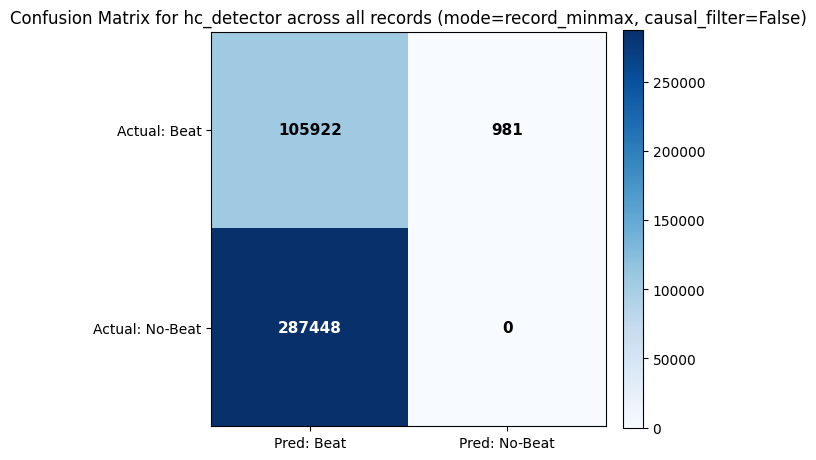


All-record evaluation summary:
records_total                                                                48
records_success                                                              46
records_failed                                                                2
tp_total                                                                 105922
fp_total                                                                 287448
fn_total                                                                    981
micro_precision_ppv                                                    0.269268
micro_recall_sensitivity                                               0.990823
micro_f1                                                               0.423457
micro_detection_error_rate                                             2.698044
tolerance_ms                                                                150
signal_mode                                                       record_minmax
apply_ca

,record_id,status,signal_csv,n_samples,n_gt_beats,tp,fp,fn,precision_ppv,recall_sensitivity,f1,detection_error_rate,windows_processed,apply_causal_filter,error_message
0,100,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2273.0,2270.0,7724.0,3.0,0.227136,0.998680,0.370099,3.399472,9994.0,False,
1,101,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1873.0,1866.0,9740.0,7.0,0.160779,0.996263,0.276875,5.203951,11607.0,False,
2,102,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '102' m...
3,103,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2090.0,2084.0,5185.0,6.0,0.286697,0.997129,0.445347,2.483732,7269.0,False,
4,104,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '104' m...
5,105,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2690.0,2643.0,10471.0,47.0,0.201540,0.982528,0.334472,3.910037,13115.0,False,
6,106,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2057.0,2034.0,9271.0,23.0,0.179920,0.988819,0.304445,4.518230,11305.0,False,
7,107,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2139.0,2133.0,7129.0,6.0,0.230296,0.997195,0.374178,3.335671,9262.0,False,
8,108,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,1823.0,1785.0,8184.0,38.0,0.179055,0.979155,0.302748,4.510148,9971.0,False,
9,109,ok,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,225694.0,2534.0,2525.0,5515.0,9.0,0.314055,0.996448,0.477587,2.179953,8040.0,False,


In [18]:
FUNCTION_TO_EVALUATE = hc_detector  

OUTPUT_CSV_FILENAME =  FUNCTION_TO_EVALUATE.__name__ + "_all_records_results.csv"   
## -------- Example run: evaluate ALL records --------
all_results_df, all_summary, all_results_csv = evaluate_all_records(
    local_dataset_dir=mit_bih_path,
    annotations_root=annotations_path,
    detector_fn=FUNCTION_TO_EVALUATE,
    fs=target_fs,
    signal_mode=SIGNAL_MODE,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=APPLY_CAUSAL_FILTER,
    causal_filter_config=CAUSAL_FILTER_CONFIG,
    output_csv_filename=OUTPUT_CSV_FILENAME,
    plot_confusion=True,
    verbose=True,
    plot_title = f"Confusion Matrix for {FUNCTION_TO_EVALUATE.__name__} across all records (mode={SIGNAL_MODE}, causal_filter={APPLY_CAUSAL_FILTER})"
)

all_results_df.head(10)

In [15]:
# # Side-by-side benchmark: NeuroKit2 vs Pan-Tompkins

# benchmark_detectors = [
#     ("neurokit", peak_detector),
#     ("pan_tompkins", pan_tompkins_peak_detector),
# ]

# benchmark_rows = []
# benchmark_outputs = {}

# record_ids_local = list_local_record_ids(mit_bih_path)
# record_id_bench = record_ids_local[0]

# for detector_name, detector_fn_bench in benchmark_detectors:
#     print(f"\n===== Benchmarking detector: {detector_name} =====")

#     # --- First-record evaluation ---
#     record_id_eval_b, x_eval_b, gt_eval_b, ann_eval_b, signal_csv_b = load_record_and_ground_truth(
#         record_id=record_id_bench,
#         annotations_root=annotations_path,
#         signal_mode=signal_mode_eval,
#     )

#     events_df_b, summary_b = evaluate_rpeak_detector_stream(
#         signal_1d=x_eval_b,
#         gt_samples=gt_eval_b,
#         detector_fn=detector_fn_bench,
#         fs=target_fs,
#         window_sec=2,
#         tolerance_ms=150,
#         apply_causal_filter=apply_causal_filter_eval,
#         causal_filter_config=causal_filter_config_eval,
#         anchor_offset_samples=20,
#     )

#     # --- All-record evaluation with detector-specific output CSV ---
#     output_csv_b = os.path.join(
#         annotations_path,
#         "evaluation",
#         f"all_records_results_{detector_name}.csv",
#     )

#     all_results_df_b, all_summary_b, all_results_csv_b = evaluate_all_records(
#         local_dataset_dir=mit_bih_path,
#         annotations_root=annotations_path,
#         detector_fn=detector_fn_bench,
#         fs=target_fs,
#         signal_mode=signal_mode_eval,
#         window_sec=2,
#         tolerance_ms=150,
#         apply_causal_filter=apply_causal_filter_eval,
#         causal_filter_config=causal_filter_config_eval,
#         output_csv_path=output_csv_b,
#         plot_confusion=False,
#         verbose=False,
#     )

#     benchmark_outputs[detector_name] = {
#         "first_record_events": events_df_b,
#         "first_record_summary": summary_b,
#         "all_results_df": all_results_df_b,
#         "all_summary": all_summary_b,
#         "all_results_csv": all_results_csv_b,
#     }

#     benchmark_rows.append({
#         "detector": detector_name,
#         "first_record_id": record_id_eval_b,
#         "first_record_tp": int(summary_b["tp"]),
#         "first_record_fp": int(summary_b["fp"]),
#         "first_record_fn": int(summary_b["fn"]),
#         "first_record_f1": float(summary_b["f1"]),
#         "all_records_success": int(all_summary_b["records_success"]),
#         "all_records_failed": int(all_summary_b["records_failed"]),
#         "all_tp_total": int(all_summary_b["tp_total"]),
#         "all_fp_total": int(all_summary_b["fp_total"]),
#         "all_fn_total": int(all_summary_b["fn_total"]),
#         "all_micro_precision": float(all_summary_b["micro_precision_ppv"]),
#         "all_micro_recall": float(all_summary_b["micro_recall_sensitivity"]),
#         "all_micro_f1": float(all_summary_b["micro_f1"]),
#         "all_micro_der": float(all_summary_b["micro_detection_error_rate"]),
#         "csv_path": all_results_csv_b,
#     })

# benchmark_compare_df = pd.DataFrame(benchmark_rows)
# print("\n=== Benchmark comparison (first record + all records) ===")
# display(benchmark_compare_df)

# print("\nSaved detector-specific CSV files:")
# for _, row in benchmark_compare_df.iterrows():
#     print(f"- {row['detector']}: {row['csv_path']}")